In [1]:
!pip install lightgbm pandas scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Import required Modules
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# Load Traffic Data
df = pd.read_csv('Traffic.csv')

In [4]:
# Simulated sample data for demonstration
n_samples = 1000
np.random.seed(42)
df = pd.DataFrame({
    'timestamp': pd.date_range(start="2025-09-01 06:00", periods=n_samples, freq='min'),
    'location_lat': np.random.uniform(12.5, 12.7, n_samples),
    'location_long': np.random.uniform(77.5, 77.7, n_samples),
    'traffic_volume': np.random.randint(50, 500, n_samples),
    'avg_speed': np.random.uniform(10, 70, n_samples),
    'congestion_level': np.random.uniform(0, 1, n_samples)  # 0-1 scale
})

In [5]:
# Feature Engineering
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
features = ['location_lat', 'location_long', 'traffic_volume', 'avg_speed', 'hour', 'weekday']
target = 'congestion_level'
X = df[features]
y = df[target]

In [6]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Train LightGBM Model
model = lgb.LGBMRegressor(
    objective='regression',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=100
)
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1025
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 0.483683
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMRegressor(objective='regression')

In [8]:
# Predict Congestion and Evaluate
y_pred = model.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score:', r2_score(y_test, y_pred))

RMSE: 0.336118578883428
R2 Score: -0.27923042853045765


In [9]:
# Route Seggestion
thresh = 0.7
congested_indices = np.where(y_pred > thresh)
suggestions = X_test.iloc[congested_indices].copy()
suggestions['predicted_congestion'] = y_pred[congested_indices]
print("Congested Areas and Suggested Alternate Times/Routes:")
print(suggestions.sort_values(by='predicted_congestion', ascending=True).head())

Congested Areas and Suggested Alternate Times/Routes:
     location_lat  location_long  traffic_volume  avg_speed  hour  weekday  \
529     12.672944      77.607832             390  47.034941    14        0   
479     12.604620      77.587117             391  43.329725    13        0   
692     12.601522      77.579733             339  40.737085    17        0   
328     12.583920      77.631742             450  31.156156    11        0   
60      12.577735      77.674735             394  66.179269     7        0   

     predicted_congestion  
529              0.700545  
479              0.706365  
692              0.714669  
328              0.724460  
60               0.726249  


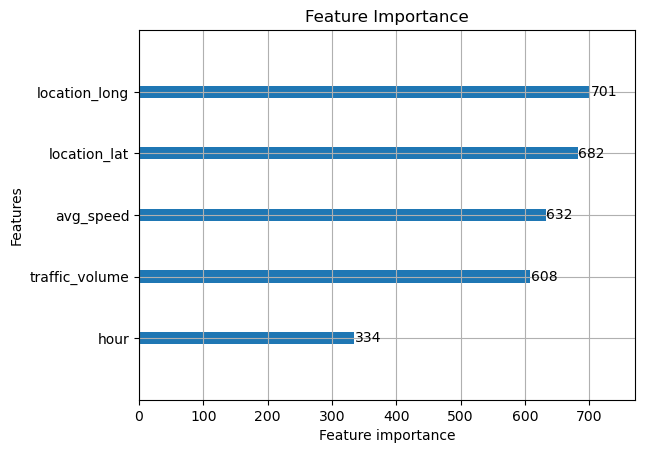

In [10]:
# Feature Visualization
lgb.plot_importance(model, max_num_features=6)
plt.title('Feature Importance')
plt.show()